# Detecting Depression — pipeline walkthrough

A quick, self-contained demonstration of the study pipeline on the committed
dataset: load the posts, look at statistics and wordclouds, extract TF-IDF and
GLoVe features, train a quick Random Forest on each, and classify new text with
the shipped trained models.

The full pipeline (sentence transformers, Optuna tuning, the 5-split
evaluation) lives in `src/` — see `README.md`.

In [1]:
import os
# run from the repository root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import re
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
for package in ['stopwords', 'punkt', 'punkt_tab', 'wordnet']:
    nltk.download(package, quiet=True)

## The dataset

989 Reddit posts: 291 written by users with a self-reported Depression
diagnosis (label 1) and 698 control posts (label 0). We use the *cleaned*
variants, from which the psychiatric keywords ("depression", "diagnosis",
"therapist", ...) have been removed — the same data the published models were
trained on.

In [2]:
def load_folder(folder, label):
    posts = []
    for filename in os.listdir(folder):
        if filename.endswith('.txt'):
            with open(os.path.join(folder, filename), encoding='utf-8') as f:
                posts.append({'text': f.read(), 'label': label})
    return posts

df = pd.DataFrame(load_folder('data/Depression_Clean', 1) + load_folder('data/Control_Clean', 0))
df

,text,label
0,"The me with in 30mn, is this normal?\nHello...",1
1,Loss of libido with no medication. Occasional ...,1
2,"intense, mind-boggling mood swings?\nhey team....",1
3,I've been with severe and moderate social an...,1
4,"with and then with Bipolar\nSo, i was with...",1
...,...,...
984,Economy class flights need regulations to esta...,0
985,What is the role of playing in adulthood?\nI f...,0
986,My brother save me from getting bullied\nSo my...,0
987,Do you guys ever just tear up at the thought o...,0


In [3]:
print("Posts per class:")
print(df['label'].value_counts())

df['num_words'] = df['text'].str.split().str.len()
print("\nMean words per post:")
print(df.groupby('label')['num_words'].mean().round(2))

Posts per class:
label
0    698
1    291
Name: count, dtype: int64

Mean words per post:
label
0    131.26
1    216.60
Name: num_words, dtype: float64


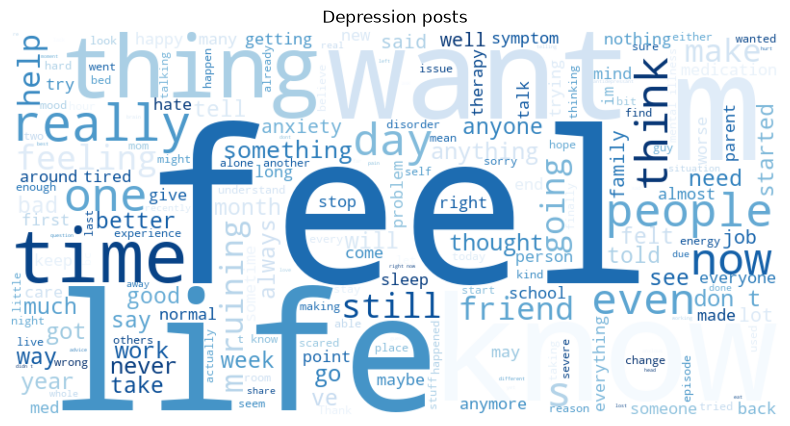

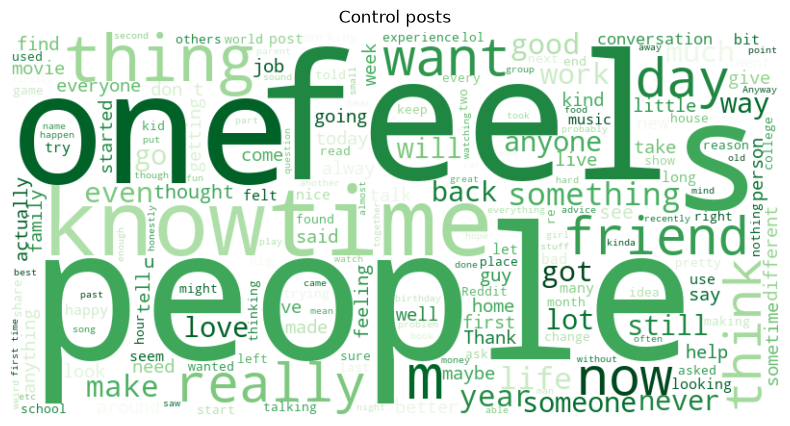

In [4]:
# Wordclouds of the two classes
for label, name, colormap in [(1, 'Depression', 'Blues'), (0, 'Control', 'Greens')]:
    text = ' '.join(df[df['label'] == label]['text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap=colormap).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{name} posts')
    plt.show()

## TF-IDF features

The feature family of the preceding conference paper: lowercase, tokenize,
drop stopwords and non-alphanumeric tokens, then TF-IDF (words appearing at
least 3 times). A default Random Forest on a 70-30 split already separates the
classes well.

In [5]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    words = nltk.word_tokenize(text.lower())
    return ' '.join(w for w in words if w.isalnum() and w not in stop_words)

df['preprocessed'] = df['text'].apply(preprocess)

vectorizer = TfidfVectorizer(min_df=3)
X_tfidf = vectorizer.fit_transform(df['preprocessed'])
print("TF-IDF matrix:", X_tfidf.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['label'], test_size=0.3, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))

TF-IDF matrix: (989, 3118)


              precision    recall  f1-score   support

           0       0.84      0.98      0.90       213
           1       0.91      0.51      0.66        84

    accuracy                           0.85       297
   macro avg       0.88      0.75      0.78       297
weighted avg       0.86      0.85      0.83       297



## GLoVe word-embeddings

Each post is represented by the mean of its words' 200-dimension GLoVe Twitter
vectors (as in `src/features_glove.py`). The pre-trained model encodes semantic
word similarity — visible in a quick sanity check — and its post embeddings
outperform TF-IDF in the study.

In [6]:
# Load the 200-dimension GLoVe Twitter model (downloads ~750 MB on first use)
import gensim.downloader as api
glove = api.load('glove-twitter-200')

from sklearn.metrics.pairwise import cosine_similarity
for word in ['sad', 'happy']:
    similarity = cosine_similarity([glove['depression']], [glove[word]])[0][0]
    print(f"similarity('depression', '{word}') = {similarity:.2f}")

similarity('depression', 'sad') = 0.40
similarity('depression', 'happy') = 0.23


In [7]:
lemmatizer = WordNetLemmatizer()

def glove_embedding(text):
    text = re.sub(r'[^a-zA-Z]+', ' ', text)
    words = [w for w in text.lower().split() if w in glove.key_to_index]
    vectors = [glove[lemmatizer.lemmatize(w)] for w in words
               if lemmatizer.lemmatize(w) in glove.key_to_index]
    return np.mean(vectors, axis=0) if vectors else np.zeros(glove.vector_size)

X_glove = np.vstack(df['text'].apply(glove_embedding))

X_train, X_test, y_train, y_test = train_test_split(
    X_glove, df['label'], test_size=0.3, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       213
           1       0.89      0.60      0.71        84

    accuracy                           0.87       297
   macro avg       0.88      0.78      0.81       297
weighted avg       0.87      0.87      0.86       297



## Inference with the trained models

`models/` ships the study's best model (All MPNet base v2 sentence-transformer
features + tuned Random Forest). `src/predict.py` applies the full pipeline —
keyword cleaning, embedding, classification — to any `.txt` file:

In [8]:
!"{sys.executable}" src/predict.py examples/example_depression.txt

Embedding the text with sentence-transformers/all-mpnet-base-v2...

Prediction: Depression (1)
Confidence: 96.8%
Model: Random Forest on sentence-transformers/all-mpnet-base-v2 features (test F1: 98.04%)

Note: this is a research demonstration, not a diagnostic tool.



Loading weights: 100%|##########| 199/199 [00:00<00:00, 2507.27it/s]


In [9]:
!"{sys.executable}" src/predict.py examples/example_control.txt

Embedding the text with sentence-transformers/all-mpnet-base-v2...

Prediction: Control (0)
Confidence: 78.6%
Model: Random Forest on sentence-transformers/all-mpnet-base-v2 features (test F1: 98.04%)

Note: this is a research demonstration, not a diagnostic tool.



Loading weights: 100%|##########| 199/199 [00:00<00:00, 3326.49it/s]
